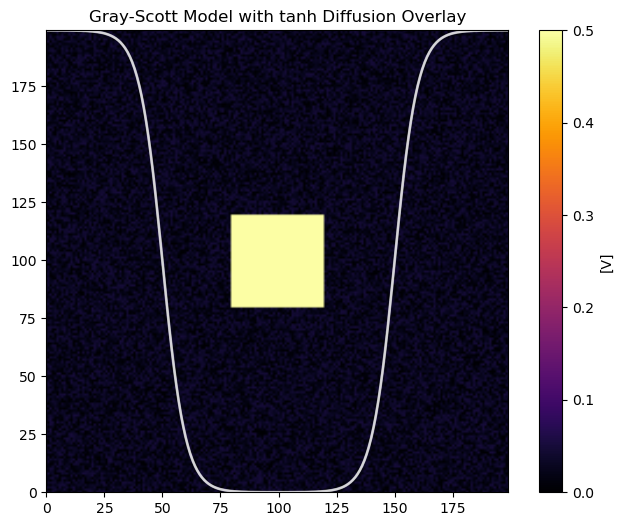

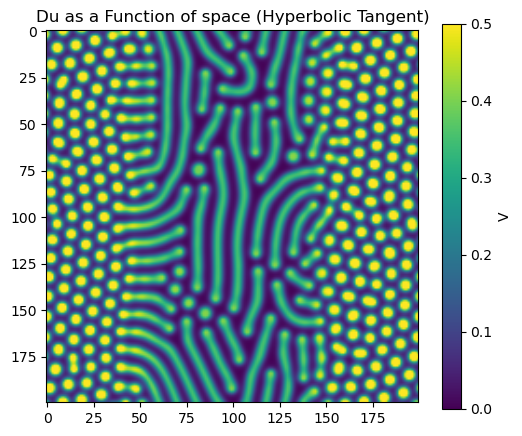

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation


F, k =  0.046, 0.064 #(Stripes) #0.028, 0.064 (Dots) #0.010, 0.046 (Dynamic) #0.037, 0.06 (Standard)
N = 200
L = 200
dx = L / N
height = 3
dy = dx
n_steps =  400 #10000 #Using 300 for video. 
p1 = 50
p2 = 200-p1
s = 0.1 #this will control how sharp the chnage in concentration will be at the boundry p1 and p2
x = np.linspace(0,L,N,endpoint=False)
y = np.linspace(0,L,N,endpoint=False)

scale = 0.16


input1 = s * (x - p1) #so, this creates a bunch of values between the two boundries and creates them into inputs for the tanh functions
input2 =  s * -1 * (x - p2)
tanfunc =   scale * ((height - 1)/2 * (2-np.tanh(input1) - np.tanh(input2)) +1) #now that we have a bunch of values between these two boundries, we can use the tanh function to create a bunch of diffusion constants between those two boundries
Du =  np.full((N,N), tanfunc) #Now a bunch of diffusion constants are created between those two boundries which all change. Each is slightly different, but the main change is at 25 and 75. So after those, the 
#diffusion constants are much lower. Currently, with sharpess = 0.1, and pi = 25 with p2 = 75, the diffusion constants are between 0 and 2. So we can define Dv later with the same process, maybe just saying that Dv = 2 * Du
Dv =  (scale/2) * np.ones_like(Du)  # Dv = 0.08 For now I have placed Dv = Du/2 because that is the ratio we have been using so far. I still don't know why works, but it does.

dt = ((dx)**2)/(4 * Du.max())-0.1 #This is the time step, which is based on the diffusion constant. This is a function for the time step. 



def first_derivative(M, axis):
    firstD = (np.roll(M, 1, axis) - np.roll(M, -1, axis)) / (2 * dx)
    return firstD
        
def combined_derivative(D, Concentration):
    dD_dx = first_derivative(D, 0)
    dU_dx = first_derivative(Concentration, 0)
    dD_dy = first_derivative(D, 1)
    dU_dy = first_derivative(Concentration, 1)
    return dD_dx * dU_dx + dD_dy * dU_dy


def laplacian(Z, dx):
    d2Z_dx2 = np.roll(Z, 1, 0) - 2 * Z + np.roll(Z, -1, 0)
    d2Z_dy2 = np.roll(Z, 1, 1) - 2 * Z + np.roll(Z, -1, 1) 

    derivative = (d2Z_dx2 + d2Z_dy2)/(dx * dx) 
    # should this not be (d2Z_dx2/dx * dx) + (d2Z_dy2/dy * dy)? I think we are saying that 
    #dy = dx. So it doesn't matter and we combine like terms. 
    return derivative

def solver(U, V, Du, Dv, F, k, dx, dt):
    Lu = laplacian(U, dx)
    Lv = laplacian(V, dx)

    uvv = U * V * V

    U += (Du * Lu + combined_derivative(Du,U) - uvv + F * (1 - U)) * dt
    V += (Dv * Lv + combined_derivative(Dv,V) + uvv - (F+k) * V) * dt
    #Here is forward euler's method for the next time step. 
    return U, V


U = np.ones((N,N))
V = np.zeros((N,N))


r = 20
U[N//2 - r:N//2+r, N//2 - r: N//2 + r] = 0.75 #orginally was 0.50
V[N//2 - r:N//2+r, N//2 - r: N//2 + r] = 0.50 #orginally was 0.25
U += 0.05 * np.random.rand(N,N)
V += 0.05 * np.random.rand(N,N)

fig, ax = plt.subplots(figsize=(8,6)) #regular sizing in a cube

im = ax.imshow(V, cmap='inferno', interpolation='bilinear', vmin=0, vmax=0.5)
plt.axis('on')
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('[V]')

tanh_y = (tanfunc - tanfunc.min()) / (tanfunc.max() - tanfunc.min()) * (N - 1)

# x-coordinates: pixel indices (0 to N-1)
x_coords = np.arange(N)

# Overlay line: static sine curve
tanh_line, = ax.plot(x_coords, tanh_y, color='white', linewidth=1.5, alpha=0.6)

# Set axes to avoid autoscaling that might hide the line
ax.set_xlim(0, N-1)
ax.set_ylim(0, N-1)

ax.set_title('Gray-Scott Model with tanh Diffusion Overlay')

# def update(frame, U, V, Du, Dv, F, k, dx, dt, tanh_line):
#     for _ in range(100):
#         U, V = solver(U, V, Du, Dv, F, k, dx, dt)
#     im.set_array(V)
#     return [im, tanh_line]
# ani = animation.FuncAnimation(fig, update, frames=n_steps, interval = 0.1, blit=True, fargs=(U, V, Du, Dv, F, k, dx, dt, tanh_line))
# #ani.save('Gray_Scott_Animation.mp4', writer='ffmpeg', fps=30, dpi=300) #Save the animation as a video file

''' SOLVE FOR CONCENTRATIONS '''

total_V_concentration = np.zeros(n_steps)
total_time = np.zeros(n_steps)

for i in range(n_steps):
    for _ in range(100):
        U, V = solver(U, V, Du, Dv, F, k, dx, dt)
    
    total_time[i] = i * dt 
    total_V_concentration[i] = np.mean(V)

# ''' PLOT FINAL TIMESTEP '''

plt.figure(figsize=(6,5))
tanh_y = (tanfunc - tanfunc.min()) / (tanfunc.max() - tanfunc.min()) * (N - 1)

# x-coordinates: pixel indices (0 to N-1)
x_coords = np.arange(N)

# Overlay line: static sine curve
tanh_line, = ax.plot(x_coords, tanh_y, color='white', linewidth=2, alpha=0.6)


plt.imshow(V, cmap='viridis', interpolation='bilinear', vmin=0, vmax=0.5)
plt.title('Du as a Function of space (Hyperbolic Tangent)')
plt.colorbar(label='V')
plt.show()






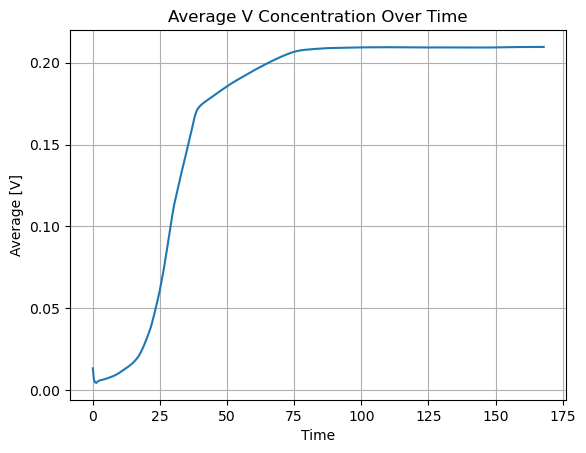

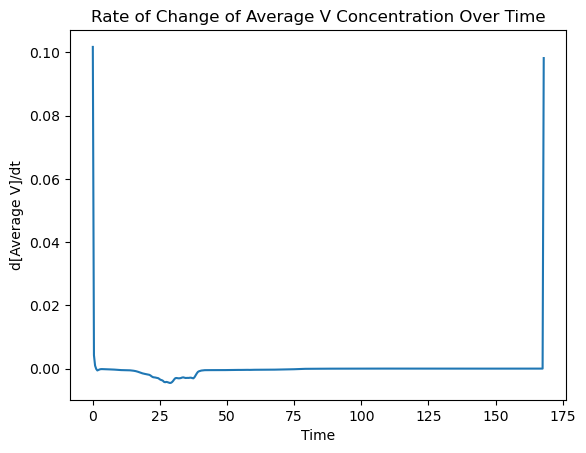

In [6]:
plt.figure()
plt.plot(total_time, total_V_concentration)
plt.title('Average V Concentration Over Time')
plt.xlabel('Time')
plt.ylabel('Average [V]')
plt.grid(True)
plt.show()

plt.figure()
plt.plot(total_time, first_derivative(total_V_concentration,0))
plt.title('Rate of Change of Average V Concentration Over Time')
plt.xlabel('Time')
plt.ylabel('d[Average V]/dt')
plt.show()

(200,) (200, 200)


[]

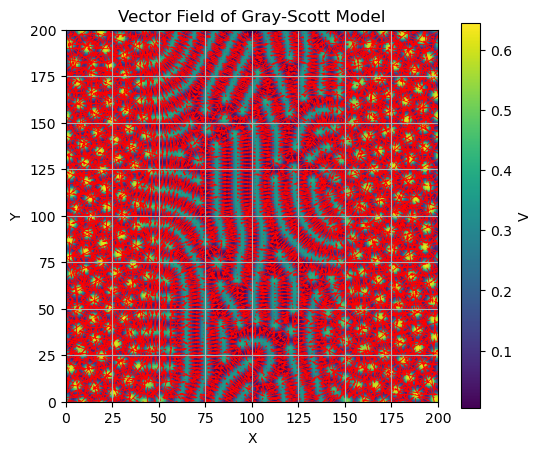

In [2]:
dVx = first_derivative(V, 1)
dVy = first_derivative(V, 0)


skip = 2 # keep as 4 regularly
print(x.shape, dVx.shape)

plt.figure(figsize=(6,5))
plt.imshow(V, cmap='viridis')
plt.title('Gray Scott')
plt.colorbar(label='V')
plt.xlim(0,200)
plt.ylim(0,200)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Vector Field of Gray-Scott Model')
plt.grid()

plt.quiver(x[::skip], y[::skip], dVx[::skip,::skip], dVy[::skip, ::skip], color='red', scale=3)

plt.plot()

p1= 50


[]

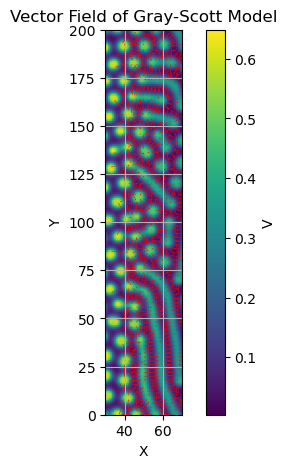

In [3]:
'''EDGE SECTION ONLY'''

x3, y3 = np.meshgrid(np.arange(N), np.arange(N))
print( 'p1=', p1)
bound = 20
mask_edge1 = x3 < p1 - 0.5*bound
mask_edge2 = x3 > p1 + bound
mask_edge = mask_edge1 | mask_edge2

final_mask_edge = mask_edge1 | mask_edge2

dVx2 =~final_mask_edge * dVx
dVy2= ~final_mask_edge * dVy

skip = 2
# Downsample both coordinate grids and vector components consistently
x_ds = x3[::skip, ::skip]
y_ds = y3[::skip, ::skip]
dVx_ds = dVx2[::skip, ::skip]
dVy_ds = dVy2[::skip, ::skip]

plt.figure(figsize=(6,5))
plt.imshow(V, cmap='viridis')
plt.colorbar(label='V')
plt.xlim(p1-bound, p1+bound)
plt.ylim(0, 200)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Vector Field of Gray-Scott Model')
plt.grid()

# Overlay vector field
plt.quiver(x_ds, y_ds, dVx_ds, dVy_ds, color='red', scale=1, width=0.005)

plt.plot()



[]

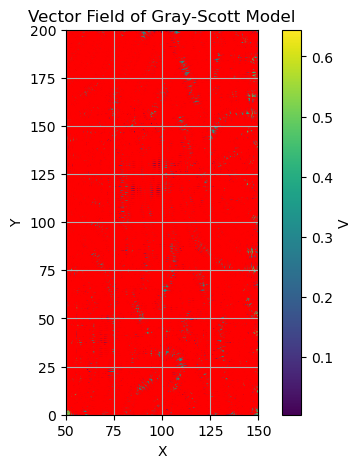

In [3]:
'''This is the mask for inner section. '''

x2, y2 = np.meshgrid(np.arange(N), np.arange(N))

mask1 = x2 < p1
mask2 = x2 > p2


final_mask = mask1 | mask2

dVx2 =~final_mask * dVx
dVy2= ~final_mask * dVy

skip = 1
# Downsample both coordinate grids and vector components consistently
x_ds = x2[::skip, ::skip]
y_ds = y2[::skip, ::skip]
dVx_ds = dVx2[::skip, ::skip]
dVy_ds = dVy2[::skip, ::skip]

plt.figure(figsize=(6,5))
plt.imshow(V, cmap='viridis')
plt.colorbar(label='V')
plt.xlim(p1,p2)
plt.ylim(0, 200)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Vector Field of Gray-Scott Model')
plt.grid()

# Overlay vector field
plt.quiver(x_ds, y_ds, dVx_ds, dVy_ds, color='red', scale=1, width=0.005)

plt.plot()

In [ ]:
'''DO NOT LOOK AT'''


'''fixing angles in a different way'''

'''Hi Saaransh, if you are reading this - I wanted to try some different logic. I had thought that why do the orginal way proposed when we could just take an unit vector in the y-direction and then when you mupltiply that with the 
gradient vector, the angle would be 90 and their dot product would be 0. Not sure if that makes sense, let me know what you think. ~ Nov 22'''

a = [0,1]

n_vector = dVx/np.sqrt(dVx**2 + dVy**2)

def dot_product(a, b):
    return a[0]*b[0] + a[1]*b[1]

cos_theta = dot_product(n_vector, a)

theta = np.arccos(cos_theta)

theta = theta * (180/np.pi) #convert to degrees

In [ ]:
'''DO NOT LOOK AT'''

'''to fix the angles'''

'''goal is to type into cos2theta'''

'''Changes as of Nov 22 ~ I have added this part that states n_vectorx and n_vectory because I thought that for most cases and for other cases, i would have n be in some direction, so I could not only use its x component. For this specefic scenario
it may suffice for only using the x component, but this makes more mathematical sense. I then made this new n_vector that is composed of the components and then use that to calculate the dot product. 

I also made sure to convert theta to degrees before masking it, because otherwise the angles were coming out to be very small values in radians - so it looked like all the angles were 0 when they were one and then some. '''

n_vectorx = dVx/np.sqrt(dVx**2 + dVy**2) 
n_vectory = dVy/np.sqrt(dVx**2 + dVy**2)

print('n_vector', np.sqrt(n_vectorx**2 + n_vectory**2))

n_vector = [n_vectorx, n_vectory]

#n_vector = dVx2/np.sqrt(dVx2**2 + dVy2**2)

a = [1,0]

def dot_product(a, b):
    return a[0]*b[0] + a[1]*b[1]

cos_sq_theta = (dot_product(n_vector,a))**2 
#print(cos_sq_theta)

cos_2_theta = 2 * cos_sq_theta - 1

theta = 0.5 * np.arccos(cos_2_theta)

theta = theta * (180/np.pi) #convert to degrees



theta =~final_mask * theta #USE FOR INNER SECTION
#theta =~final_mask_edge * theta #USE FOR EDGE SECTION



print('theta', theta)


'''this is all corrected as of Dec 29th, 2025'''





n_vector [[1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]
 ...
 [1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]]
theta [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


'this is all corrected as of Dec 29th, 2025'

Rank 1: Bin center = 0.0157, Frequency = 1661
Rank 2: Bin center = 0.0472, Frequency = 1386
Rank 3: Bin center = 0.0786, Frequency = 1336


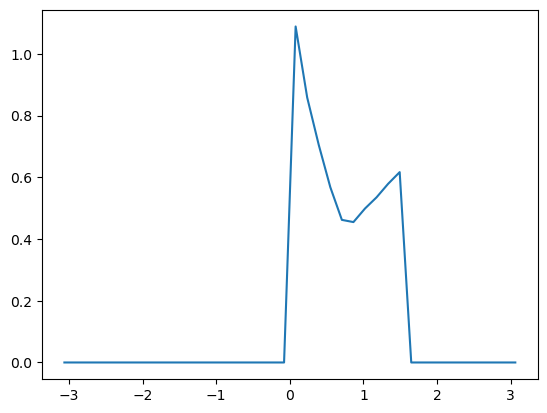

In [ ]:
'''To plot cosine theta and frequency''' 
'''LOOK HERE FOR FEB 7th, 2026'''

a = [1,0]

dV = [dVx,dVy]

resultant = dot_product(a, dV)

cos_theta = resultant / (np.sqrt(dVx**2 + dVy**2) * np.sqrt(a[0]**2 + a[1]**2))

# bins = np.linspace(-1, 1, 41)

# hist, bin_edge = np.histogram(cos_theta, bins, density=True)

# bin_label = (bins[1:] + bins[:-1])/2
# plt.plot(bin_label, hist)

#print('median:', np.median(cos_theta))

'''should cosine theta be 1? In this case, dot product we know theta is 0 so cos should be 1. '''

'''this is where we transform cosine theta to cosine 2 theta and then to theta, which is the angle between the vector and the x-axis. '''

cos_theta_squared = cos_theta**2

cos_2_theta = 2 * cos_theta_squared - 1

theta = 0.5 * np.arccos(cos_2_theta)

counts, bin_edges = np.histogram(theta, bins=50)

# Sort counts in descending order and get top 3 indices
top_indices = np.argsort(counts)[::-1][:3]

# Get the bin centers and their counts
top_bins = [( (bin_edges[i] + bin_edges[i+1]) / 2, counts[i]) for i in top_indices]

# Print results
for rank, (center, freq) in enumerate(top_bins, start=1):
    print(f"Rank {rank}: Bin center = {center:.4f}, Frequency = {freq}")
    
bins = np.linspace(-np.pi, np.pi, 41)

hist, bin_edge = np.histogram(theta, bins, density=True)



bin_label = (bins[1:] + bins[:-1])/2
plt.plot(bin_label, hist)





Rank 1: Bin center = 0.0157, Frequency = 1661
Rank 2: Bin center = 0.0472, Frequency = 1386
Rank 3: Bin center = 0.0786, Frequency = 1336
mean: 0.6946778268979474
std 0.48834404733007397


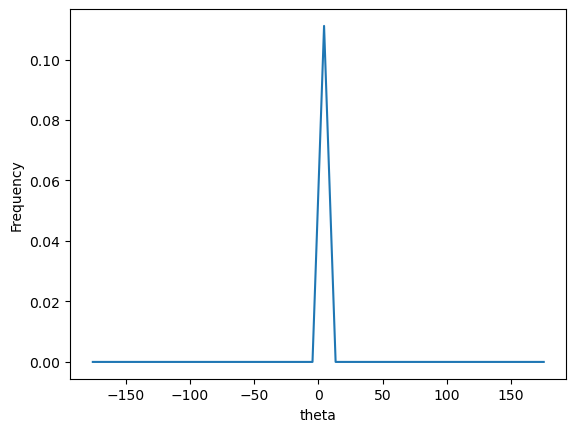

In [ ]:
# # V[V<0.1] = 0
# # V[V>0.3] = 0

# theta = np.arctan2(dVy2, dVx2) #produces values from -pi to pi
# #so if I take all the values that are -pi + theta, then add pi, I will get theta. So all the values that will be -pi + theta should be less than 0/ 

# theta[theta < 0] += np.pi #explain to Saaransh and see if that makes sense

# theta = (theta * 180)/np.pi

'''This is also here for us to look at  - Feb 7th, 2026'''

# Histogram without plotting
counts, bin_edges = np.histogram(theta, bins=50)

# Sort counts in descending order and get top 3 indices
top_indices = np.argsort(counts)[::-1][:3]

# Get the bin centers and their counts
top_bins = [( (bin_edges[i] + bin_edges[i+1]) / 2, counts[i]) for i in top_indices]

# Print results
for rank, (center, freq) in enumerate(top_bins, start=1):
    print(f"Rank {rank}: Bin center = {center:.4f}, Frequency = {freq}")


bins = np.linspace(-180, 180, 41)
#bins = np.linspace(-180,180,41)

''''''
# counts, bin_edges = np.histogram(theta, bins=bins)

# bin_centers = (bins[1:] + bins[:-1]) / 2

# plt.plot(bin_centers, counts)

''''''

hist, bin_edge = np.histogram(theta, bins, density=True)

bin_label = (bins[1:] + bins[:-1])/2
plt.plot(bin_label, hist)



# plt.hist(theta, bins=10,density=True)

print('mean:',np.mean(theta))
print('std',np.std(theta))

# plt.ylim(0,30)
plt.xlabel('theta')
plt.ylabel('Frequency')
plt.show()



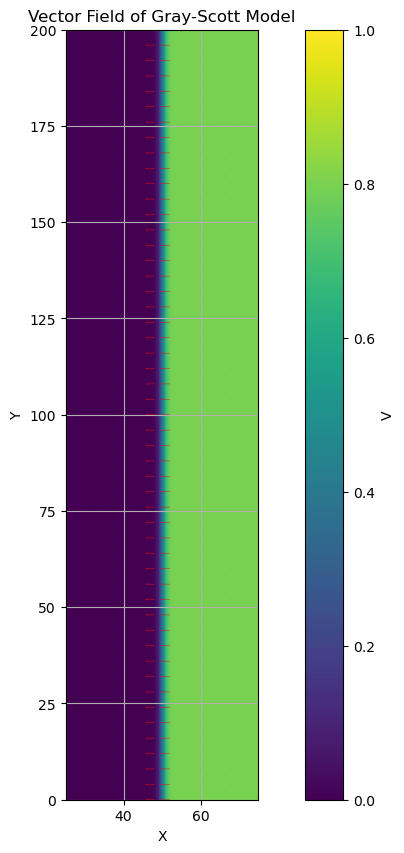

In [16]:

V2 = np.full((N,N), 0.4 * (np.tanh(x - 50) - np.tanh(x - 150)))

dVx = first_derivative(V2, 1)
dVy = first_derivative(V2, 0)


skip = 4 # keep as 4 regularly

plt.figure(figsize=(12,10))
plt.imshow(V2, cmap='viridis', interpolation='bilinear', vmin=0, vmax=1)
plt.title('Gray Scott')
plt.colorbar(label='V')
plt.xlim(25,75)
plt.ylim(0,200)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Vector Field of Gray-Scott Model')
plt.grid()

plt.quiver(x[::skip], y[::skip], dVx[::skip,::skip], dVy[::skip, ::skip], color='red', scale=1)

plt.show()